In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pickle
import shap

In [4]:

# Load model
with open("models/baseline_models/cardio_xgb_baseline_model.pkl", "rb") as f:
    model = pickle.load(f)

# Load test data (just to get column order)
test_df = pd.read_csv("data/test_train_val_sets/cardio_baseline_test.csv")
X_test  = test_df.drop(columns=["cardio", "stratify"])

# Recreate explainer from loaded model
explainer = shap.TreeExplainer(model)

C:\Users\kavis\AppData\Local\Temp\ipykernel_38704\2554179124.py:96: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kavis\AppData\Local\Temp\ipykernel_38704\2554179124.py:97: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("clinical_heatstrip.png", dpi=150,
c:\Users\kavis\OneDrive\Desktop\Study Resources\Year 3\Diss\Code\Dissertation_ExplainableAI\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


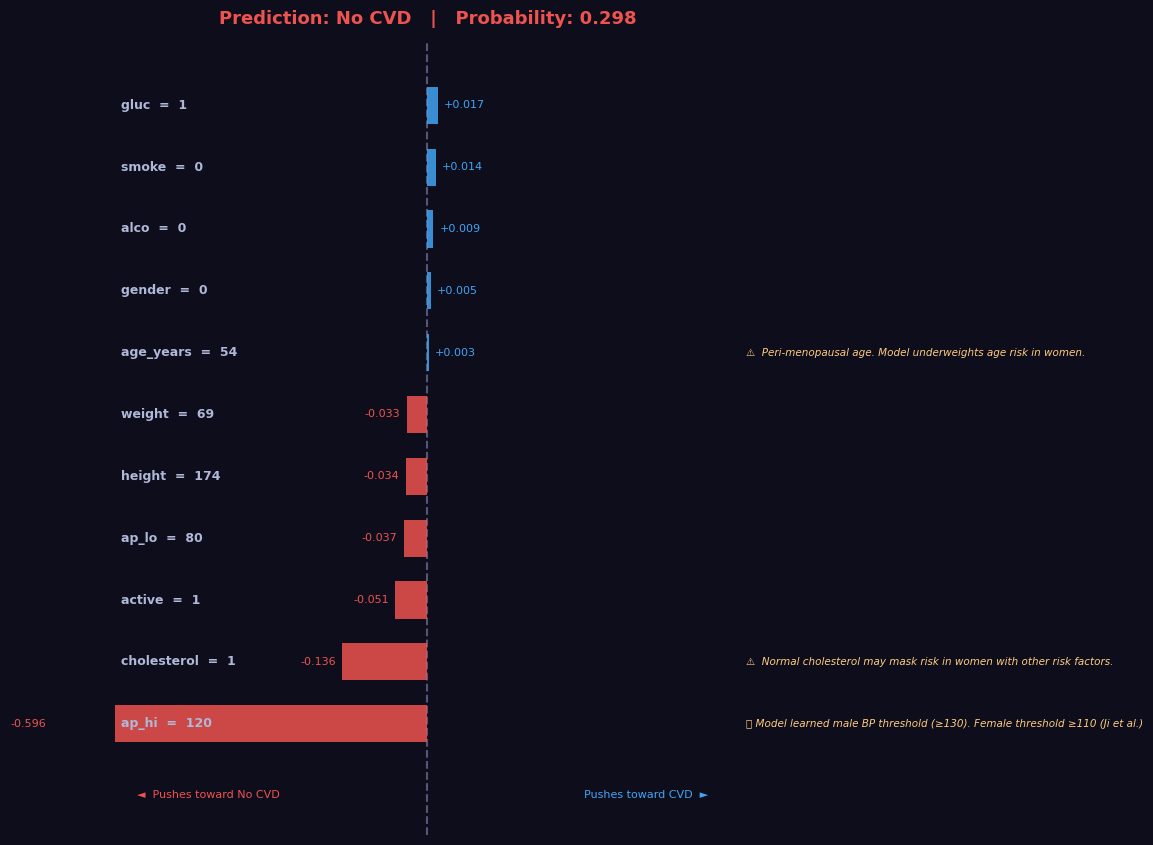


Prediction  : No CVD
Probability : 0.298

⚠️  Bias flags detected (3):
   ap_hi = 120 → 🔴 Model learned male BP threshold (≥130). Female threshold ≥110 (Ji et al.)
   cholesterol = 1 → ⚠️  Normal cholesterol may mask risk in women with other risk factors.
   age_years = 54 → ⚠️  Peri-menopausal age. Model underweights age risk in women.


,feature,value,shap,flag
3,ap_hi,120,-0.595882,🔴 Model learned male BP threshold (≥130). Fema...
5,cholesterol,1,-0.135610,⚠️ Normal cholesterol may mask risk in women ...
9,active,1,-0.051083,
4,ap_lo,80,-0.037094,
1,height,174,-0.034377,
2,weight,69,-0.032557,
10,age_years,54,0.002612,⚠️ Peri-menopausal age. Model underweights ag...
0,gender,0,0.005441,
8,alco,0,0.009460,
7,smoke,0,0.013746,


In [5]:


def clinical_heatstrip(patient_dict, model=model, explainer=explainer, X_ref=X_test):
    """
    patient_dict: dict of feature values e.g.
    {
        "age_years": 54, "gender": 0, "weight": 69,
        "ap_hi": 120,   "ap_lo": 80, "cholesterol": 1,
        "gluc": 1,      "smoke": 0,  "alco": 0,
        "active": 1,    "height": 174
    }
    """

    # ── 1. Build input & get prediction ──────────────────────────────────
    input_df = pd.DataFrame([patient_dict])[X_ref.columns]
    prob     = model.predict_proba(input_df.values)[0, 1]
    pred     = "CVD" if prob >= 0.5 else "No CVD"

    # ── 2. SHAP values ────────────────────────────────────────────────────
    sv       = explainer(input_df)
    shap_vals = sv[0].values
    features  = X_ref.columns.tolist()

    shap_df = pd.DataFrame({
        "feature":  features,
        "value":    input_df.values[0],
        "shap":     shap_vals,
    }).sort_values("shap")  # most negative at top

    # ── 3. Bias flag logic ────────────────────────────────────────────────
    def get_bias_flag(row):
        if row["feature"] == "ap_hi" and 110 <= row["value"] < 130 and row["shap"] < 0:
            return "🔴 Model learned male BP threshold (≥130). Female threshold ≥110 (Ji et al.)"
        if row["feature"] == "age_years" and row["value"] >= 52 and row["shap"] < 0.02:
            return "⚠️  Peri-menopausal age. Model underweights age risk in women."
        if row["feature"] == "cholesterol" and row["value"] == 1 and row["shap"] < 0:
            return "⚠️  Normal cholesterol may mask risk in women with other risk factors."
        return ""

    shap_df["flag"] = shap_df.apply(get_bias_flag, axis=1)

    # ── 4. Plot ───────────────────────────────────────────────────────────
    n        = len(shap_df)
    fig, ax  = plt.subplots(figsize=(12, n * 0.55 + 2.5))
    fig.patch.set_facecolor("#0d0d1b")
    ax.set_facecolor("#0d0d1b")

    max_shap = max(abs(shap_df["shap"].max()), abs(shap_df["shap"].min()), 0.01)

    for i, (_, row) in enumerate(shap_df.iterrows()):
        norm_val  = row["shap"] / max_shap          # -1 to +1
        bar_width = abs(norm_val) * 0.6             # max half-width = 0.6
        color     = "#ef5350" if row["shap"] < 0 else "#42a5f5"
        x_start   = 0.5 - bar_width if row["shap"] < 0 else 0.5

        # Heat strip bar
        ax.barh(i, bar_width, left=x_start, height=0.6,
                color=color, alpha=0.85, zorder=2)

        # Feature label (left)
        ax.text(0.01, i, f"{row['feature']}  =  {row['value']}",
                va="center", ha="left", fontsize=9,
                color="#b0b8d8", fontweight="bold")

        # SHAP value (right of bar)
        shap_x = 0.5 + bar_width + 0.01 if row["shap"] >= 0 else 0.5 - bar_width - 0.01
        ha     = "left" if row["shap"] >= 0 else "right"
        ax.text(shap_x, i, f"{row['shap']:+.3f}",
                va="center", ha=ha, fontsize=8, color=color)

        # Bias flag (far right)
        if row["flag"]:
            ax.text(1.01, i, row["flag"],
                    va="center", ha="left", fontsize=7.5,
                    color="#ffcc80", style="italic",
                    transform=ax.get_yaxis_transform())

    # Centre line
    ax.axvline(x=0.5, color="#555577", linewidth=1.5, linestyle="--", zorder=1)

    # Axis labels
    ax.text(0.15, -1.2, "◄  Pushes toward No CVD",
            ha="center", fontsize=8, color="#ef5350")
    ax.text(0.85, -1.2, "Pushes toward CVD  ►",
            ha="center", fontsize=8, color="#42a5f5")

    # Title block
    pred_color = "#42a5f5" if pred == "CVD" else "#ef5350"
    ax.set_title(
        f"Prediction: {pred}   |   Probability: {prob:.3f}",
        fontsize=13, fontweight="bold", color=pred_color, pad=14
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(-1.8, n)
    ax.axis("off")

    plt.tight_layout()
    plt.savefig("clinical_heatstrip.png", dpi=150,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

    # ── 5. Console summary ────────────────────────────────────────────────
    print(f"\nPrediction  : {pred}")
    print(f"Probability : {prob:.3f}")
    flags = shap_df[shap_df["flag"] != ""]
    if not flags.empty:
        print(f"\n⚠️  Bias flags detected ({len(flags)}):")
        for _, row in flags.iterrows():
            print(f"   {row['feature']} = {row['value']} → {row['flag']}")
    else:
        print("\n✅ No bias flags detected.")

    return shap_df


# ── Hardcoded test ────────────────────────────────────────────────────────────
clinical_heatstrip({
    "age_years": 54,
    "gender":    0,
    "weight":    69,
    "ap_hi":     120,
    "ap_lo":     80,
    "cholesterol": 1,
    "gluc":      1,
    "smoke":     0,
    "alco":      0,
    "active":    1,
    "height":    174,
})

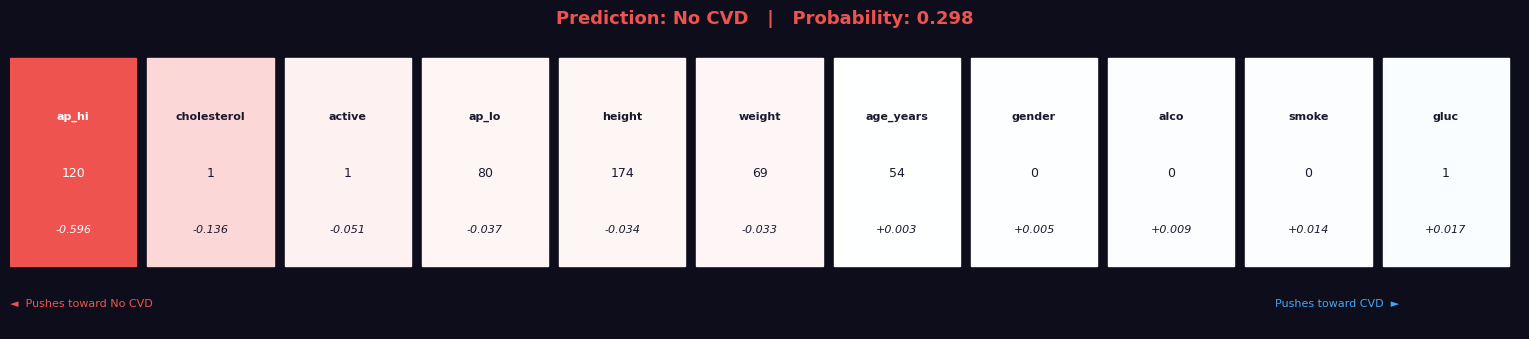

,feature,value,shap
3,ap_hi,120,-0.595882
5,cholesterol,1,-0.135610
9,active,1,-0.051083
4,ap_lo,80,-0.037094
1,height,174,-0.034377
2,weight,69,-0.032557
10,age_years,54,0.002612
0,gender,0,0.005441
8,alco,0,0.009460
7,smoke,0,0.013746


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def heatstrip(patient_dict, model=model, explainer=explainer, X_ref=X_test):
    """
    patient_dict: dict of feature values
    """

    # ── 1. Build input & get prediction ──────────────────────────────────
    input_df  = pd.DataFrame([patient_dict])[X_ref.columns]
    prob      = model.predict_proba(input_df.values)[0, 1]
    pred      = "CVD" if prob >= 0.5 else "No CVD"

    # ── 2. SHAP values ────────────────────────────────────────────────────
    sv        = explainer(input_df)
    shap_vals = sv[0].values
    features  = X_ref.columns.tolist()

    shap_df = pd.DataFrame({
        "feature": features,
        "value":   input_df.values[0],
        "shap":    shap_vals,
    }).sort_values("shap")  # most negative first (left to right)

    # ── 3. Color map: red → white → blue ─────────────────────────────────
    cmap     = mcolors.LinearSegmentedColormap.from_list(
        "shap_cmap", ["#ef5350", "#ffffff", "#42a5f5"]
    )
    max_abs  = shap_df["shap"].abs().max()
    norm     = mcolors.Normalize(vmin=-max_abs, vmax=max_abs)

    # ── 4. Plot ───────────────────────────────────────────────────────────
    n_features = len(shap_df)
    fig, ax    = plt.subplots(figsize=(n_features * 1.4, 3.5))
    fig.patch.set_facecolor("#0d0d1b")
    ax.set_facecolor("#0d0d1b")

    for i, (_, row) in enumerate(shap_df.iterrows()):
        color = cmap(norm(row["shap"]))

        # Block
        rect = plt.Rectangle([i, 0], 0.92, 1,
                              color=color, zorder=2)
        ax.add_patch(rect)

        # Text color — dark on light blocks, light on dark blocks
        r, g, b, _ = color
        brightness = 0.299*r + 0.587*g + 0.114*b
        txt_color  = "#1a1a2e" if brightness > 0.55 else "#ffffff"

        # Feature name
        ax.text(i + 0.46, 0.72, row["feature"],
                ha="center", va="center",
                fontsize=8, fontweight="bold", color=txt_color)

        # Raw value
        val_str = f"{int(row['value'])}" if row["value"] == int(row["value"]) else f"{row['value']:.2f}"
        ax.text(i + 0.46, 0.45, val_str,
                ha="center", va="center",
                fontsize=9, color=txt_color)

        # SHAP value
        ax.text(i + 0.46, 0.18, f"{row['shap']:+.3f}",
                ha="center", va="center",
                fontsize=8, color=txt_color, style="italic")

    # ── 5. Title ──────────────────────────────────────────────────────────
    pred_color = "#42a5f5" if pred == "CVD" else "#ef5350"
    ax.set_title(
        f"Prediction: {pred}   |   Probability: {prob:.3f}",
        fontsize=13, fontweight="bold",
        color=pred_color, pad=10
    )

    # ── 6. Legend strip ───────────────────────────────────────────────────
    ax.text(0, -0.15, "◄  Pushes toward No CVD",
            fontsize=8, color="#ef5350", va="top")
    ax.text(n_features * 0.92, -0.15, "Pushes toward CVD  ►",
            fontsize=8, color="#42a5f5", va="top", ha="right")

    ax.set_xlim(0, n_features)
    ax.set_ylim(-0.3, 1.1)
    ax.axis("off")

    plt.tight_layout()
    plt.savefig("heatstrip.png", dpi=150,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

    return shap_df


# ── Hardcoded test ────────────────────────────────────────────────────────────
heatstrip({
    "age_years": 54,
    "gender":    0,
    "weight":    69,
    "ap_hi":     120,
    "ap_lo":     80,
    "cholesterol": 1,
    "gluc":      1,
    "smoke":     0,
    "alco":      0,
    "active":    1,
    "height":    174,
})